# Olist Initial Purchase Random Forest

## Project objective

This notebook builds a **baseline Random Forest classifier** for predicting whether a customer makes a repeat purchase within 90 days of their initial purchase. It deliberately preserves the Logistic Regression experiment's source table, complete-case population, eight raw predictors, chronological split, customers, leakage protections, target, and evaluation population. This makes the results an apples-to-apples algorithm comparison.

A Random Forest combines predictions from many decision trees. Each tree learns nonlinear splits and interactions from a bootstrap sample while considering a random subset of features. Averaging the trees usually makes the result more stable than one decision tree. We test it after Logistic Regression to see whether nonlinear relationships or interactions provide useful signal without adding features or changing the experiment.

In [1]:
# Core libraries handle tabular data, calculations, and the importance chart.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SQLAlchemy loads the prepared PostgreSQL table; scikit-learn supplies preprocessing, modeling, and evaluation tools.
from sqlalchemy import create_engine
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve, auc
)

## Load the modeling table

The data is read without changing PostgreSQL. The source is exactly `customer_initial_purchase_model`, as in the Logistic Regression notebook.

In [2]:
# Create a reusable connection to the local PostgreSQL database that holds the modeling table.
engine = create_engine("postgresql+psycopg2://marcusromeo@localhost:5432/olist_project")
# Load the already-prepared customer-level table into a DataFrame for analysis in Python.
df = pd.read_sql("SELECT * FROM customer_initial_purchase_model", engine)
print(f"Loaded {len(df):,} customers and {df.shape[1]} columns.")
df.head()

Loaded 87,008 customers and 13 columns.


,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,98af3235f3dc55bc74cb8932c64b3523,No,BA,2018-04-22 14:26:17,125.33,102.90,22.43,1.0,1.0,1.0,1.0,4.0,0.178968
1,494e875bef93610d10c951763389f74e,No,RJ,2017-05-15 12:55:13,77.75,60.08,17.67,1.0,1.0,1.0,1.0,5.0,0.227267
2,3a1aed3a4ca113b4909b06889ecba01b,No,SP,2018-05-14 15:36:23,104.76,89.98,14.78,2.0,1.0,1.0,1.0,1.0,0.141084
3,2ab7fad20e1c4c7747dfc91137b862cf,No,SP,2017-03-19 12:41:44,119.99,99.99,20.00,1.0,1.0,1.0,1.0,2.0,0.166681
4,f714fd5260fc9d9f1b9628afe96e488a,No,RS,2017-11-27 14:54:37,85.92,69.99,15.93,1.0,1.0,1.0,1.0,4.0,0.185405


## Preserve the same complete-case modeling population

The reference experiment first excludes 657 customers missing `first_order_amount`, then drops the one remaining row with a missing value (`payment_installments`). Repeating those exact operations preserves its 86,350-customer complete-case population. Assertions make any unexpected source-data change visible rather than silently changing the experiment.

In [3]:
# Reproduce the reference experiment's filtering order so both models use the same eligible customers.
df_model = df.dropna(subset=["first_order_amount"])
# Complete-case filtering removes the final row with any missing predictor or target value.
df_final = df_model.dropna().copy()

# These checks fail loudly if the source data or filtering changes, protecting an apples-to-apples comparison.
assert df.shape == (87008, 13)
assert df_model.shape == (86351, 13)
assert df_final.shape == (86350, 13)
assert not df_final.isna().any().any()
print(f"Final complete-case population: {len(df_final):,} customers")

Final complete-case population: 86,350 customers


## Target, predictors, and leakage protection

The target remains `repeat_purchase_90d` (No = 0, Yes = 1). The same eight raw predictors describe only the customer and initial purchase. Customer ID, the split date, target, and other table columns are excluded from model inputs. Preprocessing will be fit on training customers only, protecting the future testing period from leakage.

In [4]:
# Predictors describe only the initial purchase, keeping later behavior out of the model and avoiding leakage.
feature_columns = [
    "customer_state",
    "first_order_amount",
    "freight_to_order_ratio",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
]
# The target records the outcome the model should learn: whether a repeat purchase occurred within 90 days.
target_column = "repeat_purchase_90d"
print(f"Raw predictors ({len(feature_columns)}): {feature_columns}")

Raw predictors (8): ['customer_state', 'first_order_amount', 'freight_to_order_ratio', 'products_ordered', 'unique_products_ordered', 'number_of_categories', 'number_of_sellers', 'payment_installments']


## Preserve the chronological train/test split

The cutoff is the same 80th-percentile observation used by the Logistic Regression notebook. Earlier customers (including the cutoff timestamp) form training data; later customers form the untouched test population. Customer IDs are compared with independently reconstructed reference masks to confirm exact membership.

In [5]:
# Split by time so training uses the earliest 80% of customers and testing mimics predictions on later customers.
cutoff_date = df_final["first_order_date"].sort_values().iloc[int(len(df_final) * 0.80)]
train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

# X contains the input features; y contains the single outcome the classifier must predict.
X_train, X_test = train[feature_columns], test[feature_columns]
# Scikit-learn classifiers expect numeric labels, so map No/Yes to the negative/positive classes 0/1.
y_train = train[target_column].map({"No": 0, "Yes": 1})
y_test = test[target_column].map({"No": 0, "Yes": 1})

# Rebuild the expected ID groups independently, then verify the split has exactly the intended customers.
reference_train_ids = set(df_final.loc[df_final["first_order_date"] <= cutoff_date, "customer_unique_id"])
reference_test_ids = set(df_final.loc[df_final["first_order_date"] > cutoff_date, "customer_unique_id"])
assert set(train["customer_unique_id"]) == reference_train_ids
assert set(test["customer_unique_id"]) == reference_test_ids
# Fixed cutoff, sizes, and class counts guard against silent drift that would invalidate experiment comparisons.
assert cutoff_date == pd.Timestamp("2018-04-24 14:16:45")
assert (len(train), len(test)) == (69081, 17269)
assert y_train.value_counts().to_dict() == {0: 67622, 1: 1459}
assert y_test.value_counts().to_dict() == {0: 17043, 1: 226}

print(f"Cutoff: {cutoff_date}")
print(f"Train rows: {len(train):,}; target counts: {y_train.value_counts().sort_index().to_dict()}")
print(f"Test rows:  {len(test):,}; target counts: {y_test.value_counts().sort_index().to_dict()}")

Cutoff: 2018-04-24 14:16:45
Train rows: 69,081; target counts: {0: 67622, 1: 1459}
Test rows:  17,269; target counts: {0: 17043, 1: 226}


## Random-Forest preprocessing

`customer_state` remains one-hot encoded with unknown states ignored, which converts it to numeric indicators compatible with scikit-learn and safely handles a state that might appear only in testing. Numeric predictors pass through unchanged: tree models split on ordered values and do not require `StandardScaler`. The transformer is fit only on training data, then applied to both periods.

In [6]:
# State is categorical; every other selected predictor is already numeric.
categorical_features = ["customer_state"]
numeric_features = [column for column in feature_columns if column not in categorical_features]

# ColumnTransformer applies the appropriate preparation to each feature type in one consistent object.
preprocessor = ColumnTransformer(
    transformers=[
        # Tree splits do not depend on feature scale, so numeric columns can pass through unchanged.
        ("numeric", "passthrough", numeric_features),
        # One-hot encoding gives each state its own indicator; ignore unseen test states instead of failing.
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
# Learn encoding categories only from training data to prevent test information from leaking into preprocessing.
X_train_processed = preprocessor.fit_transform(X_train)
# Reuse the fitted training transformation so test data is represented by exactly the same columns.
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
print(f"Processed shapes: train {X_train_processed.shape}, test {X_test_processed.shape}")
print(feature_names)

Processed shapes: train (69081, 34), test (17269, 34)
['numeric__first_order_amount' 'numeric__freight_to_order_ratio'
 'numeric__products_ordered' 'numeric__unique_products_ordered'
 'numeric__number_of_categories' 'numeric__number_of_sellers'
 'numeric__payment_installments' 'categorical__customer_state_AC'
 'categorical__customer_state_AL' 'categorical__customer_state_AM'
 'categorical__customer_state_AP' 'categorical__customer_state_BA'
 'categorical__customer_state_CE' 'categorical__customer_state_DF'
 'categorical__customer_state_ES' 'categorical__customer_state_GO'
 'categorical__customer_state_MA' 'categorical__customer_state_MG'
 'categorical__customer_state_MS' 'categorical__customer_state_MT'
 'categorical__customer_state_PA' 'categorical__customer_state_PB'
 'categorical__customer_state_PE' 'categorical__customer_state_PI'
 'categorical__customer_state_PR' 'categorical__customer_state_RJ'
 'categorical__customer_state_RN' 'categorical__customer_state_RO'
 'categorical__cust

## Train the baseline Random Forest

The model uses every `RandomForestClassifier` default except `random_state=42`, which makes the bootstrap sampling and feature selection reproducible. There is no tuning, cross-validation, resampling, SMOTE, class weighting, threshold change, feature engineering, or additional feature removal.

In [7]:
# Build the Random Forest; random_state=42 makes its sampling and feature randomness reproducible.
model = RandomForestClassifier(random_state=42)
# Fit lets the forest learn decision rules from the processed training features and known outcomes.
model.fit(X_train_processed, y_train)
model

RandomForestClassifier(random_state=42)

## Predictions and evaluation

Class predictions use the unchanged 0.50 threshold. Positive-class probabilities support threshold-independent ROC-AUC and PR-AUC. The same metrics are also computed on training data to reveal obvious overfitting; the held-out chronological test metrics remain the basis for comparing algorithms.

In [8]:
# Evaluate thresholded class decisions and probability-based ranking quality in one reusable function.
def evaluate_model(y_true, predictions, probabilities):
    # The precision-recall curve is especially informative when repeat purchasers are rare.
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, probabilities)
    # Classification metrics use 0/1 decisions; ROC-AUC and PR-AUC use probability rankings.
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": auc(recall_curve, precision_curve),
        "positive_predictions": int(predictions.sum()),
    }

# predict returns final classes at the default threshold; predict_proba returns confidence for ranking and AUC metrics.
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)
y_train_proba = model.predict_proba(X_train_processed)[:, 1]
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

train_metrics = evaluate_model(y_train, y_train_pred, y_train_proba)
test_metrics = evaluate_model(y_test, y_test_pred, y_test_proba)

# The confusion matrix counts true/false negatives and positives, exposing errors hidden by accuracy alone.
print("Test confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nMetrics at the default 0.50 threshold (ranking metrics use probabilities):")
pd.DataFrame([train_metrics, test_metrics], index=["Training", "Testing"])

Test confusion matrix:
[[17021    22]
 [  226     0]]

Metrics at the default 0.50 threshold (ranking metrics use probabilities):


,accuracy,precision,recall,f1,roc_auc,pr_auc,positive_predictions
Training,0.993978,0.984215,0.726525,0.835962,0.997154,0.932991,1077
Testing,0.985639,0.000000,0.000000,0.000000,0.508648,0.013461,22


In [9]:
# Print the test metrics individually so positive-class performance is easy to inspect despite class imbalance.
print(f"Test accuracy: {test_metrics['accuracy']:.3%}")
print(f"Test positive-class precision: {test_metrics['precision']:.4f}")
print(f"Test positive-class recall: {test_metrics['recall']:.4f}")
print(f"Test positive-class F1: {test_metrics['f1']:.4f}")
print(f"Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"Test PR-AUC: {test_metrics['pr_auc']:.4f}")
print(f"Positive predictions at 0.50: {test_metrics['positive_predictions']:,}")

Test accuracy: 98.564%
Test positive-class precision: 0.0000
Test positive-class recall: 0.0000
Test positive-class F1: 0.0000
Test ROC-AUC: 0.5086
Test PR-AUC: 0.0135
Positive predictions at 0.50: 22


## Feature importance

Impurity-based importance summarizes how much each processed feature reduced tree impurity across the forest. The chart shows every numeric predictor and every state indicator; the table also aggregates the state indicators back to the raw `customer_state` feature for an eight-predictor view. Importance can favor continuous or high-cardinality features and **does not imply causation**, effect direction, or business impact.

,importance
freight_to_order_ratio,0.439378
first_order_amount,0.433990
payment_installments,0.059263
customer_state,0.044300
products_ordered,0.011888
unique_products_ordered,0.005051
number_of_categories,0.003888
number_of_sellers,0.002241


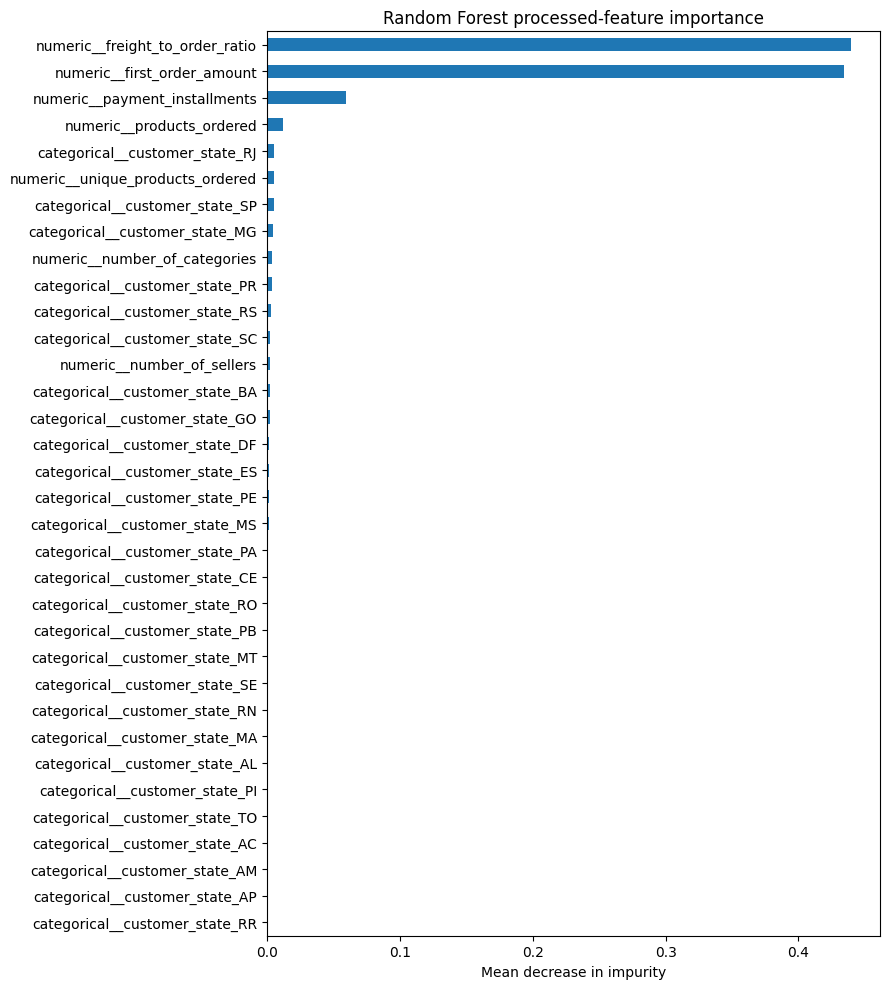

In [10]:
# Forest importance measures how much each processed feature reduces impurity across the trees.
processed_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
# Sum all one-hot state indicators to recover one overall importance for the original customer_state feature.
raw_importance = pd.Series({
    **{column: processed_importance[f"numeric__{column}"] for column in numeric_features},
    "customer_state": processed_importance[processed_importance.index.str.startswith("categorical__customer_state_")].sum(),
}).sort_values(ascending=False)
display(raw_importance.rename("importance").to_frame())

processed_importance.sort_values().plot.barh(figsize=(9, 10), title="Random Forest processed-feature importance")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## Direct comparison with Logistic Regression

The published Logistic Regression baseline below used the identical testing population. Deltas are Random Forest minus Logistic Regression. Accuracy is shown as a proportion in the table (for example, 0.98691 = 98.691%).

In [11]:
# Keep the earlier Logistic Regression results fixed for a direct same-population benchmark.
logistic_baseline = {
    "accuracy": 0.98691,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "roc_auc": 0.5063,
    "pr_auc": 0.0154,
}
# Align matching metrics side by side and calculate how much the Random Forest changes each one.
comparison_metrics = list(logistic_baseline)
comparison = pd.DataFrame({
    "Logistic Regression": pd.Series(logistic_baseline),
    "Random Forest": pd.Series({key: test_metrics[key] for key in comparison_metrics}),
})
comparison["RF minus Logistic"] = comparison["Random Forest"] - comparison["Logistic Regression"]
comparison

,Logistic Regression,Random Forest,RF minus Logistic
accuracy,0.98691,0.985639,-0.001271
precision,0.00000,0.000000,0.000000
recall,0.00000,0.000000,0.000000
f1,0.00000,0.000000,0.000000
roc_auc,0.50630,0.508648,0.002348
pr_auc,0.01540,0.013461,-0.001939


In [12]:
# Compare probability-ranking metrics because accuracy can look strong when the positive class is rare.
roc_delta = test_metrics["roc_auc"] - logistic_baseline["roc_auc"]
pr_delta = test_metrics["pr_auc"] - logistic_baseline["pr_auc"]
if roc_delta > 0.01 and pr_delta > 0:
    verdict = "better on both ranking metrics, although practical usefulness still depends on their absolute levels"
elif roc_delta < -0.01 and pr_delta < 0:
    verdict = "worse on both ranking metrics"
else:
    verdict = "effectively equivalent overall because the ranking differences are small or mixed"

# A much higher training ROC-AUC than testing ROC-AUC signals that the forest learned training-specific patterns.
overfit_gap = train_metrics["roc_auc"] - test_metrics["roc_auc"]
print(f"Comparison verdict: Random Forest is {verdict}.")
print(f"Training-to-testing ROC-AUC gap: {overfit_gap:.4f}")
print("A large training advantage, especially near-perfect training metrics with weak testing metrics, is evidence of overfitting.")

Comparison verdict: Random Forest is effectively equivalent overall because the ranking differences are small or mixed.
Training-to-testing ROC-AUC gap: 0.4885
A large training advantage, especially near-perfect training metrics with weak testing metrics, is evidence of overfitting.


## Interpretation

Use the executed outputs above as the reproducible record of this experiment. With a rare positive class, high accuracy can mostly reflect predicting non-repeat purchasers, so positive-class precision, recall, F1, ROC-AUC, and PR-AUC are essential. The unchanged 0.50 threshold answers the apples-to-apples baseline question; threshold selection, class balancing, tuning, cross-validation, and new features are intentionally outside this experiment.

Training results are diagnostic rather than an estimate of future performance. A much stronger training result than chronological testing result indicates that the flexible forest learned patterns specific to historical customers that did not generalize. Feature importance describes model reliance, not causal drivers of repeat purchasing.